树结构
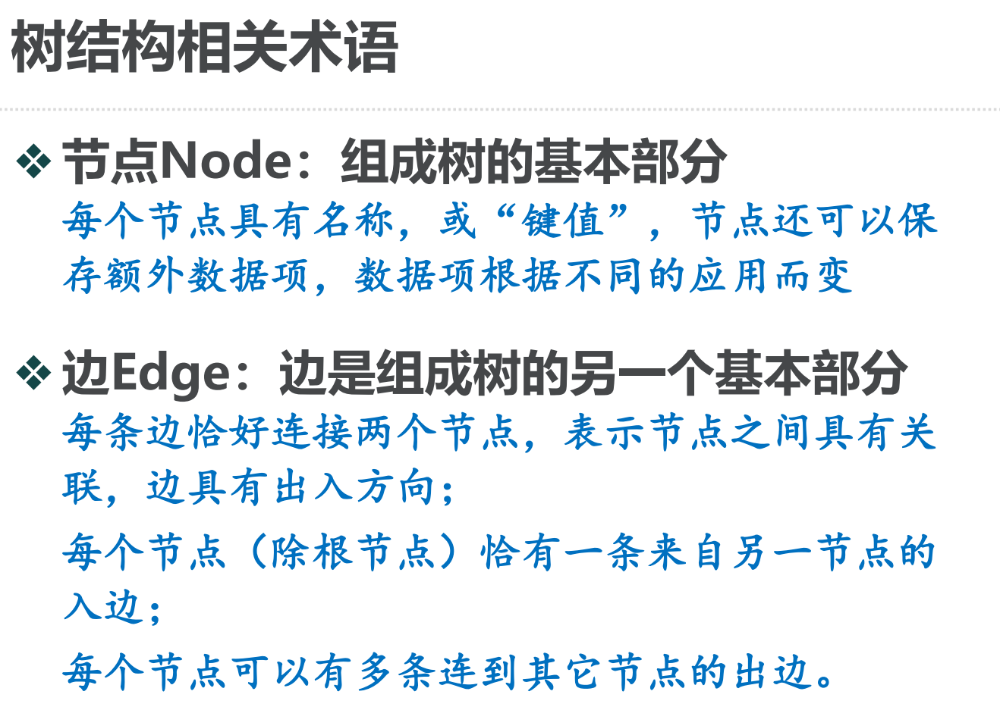

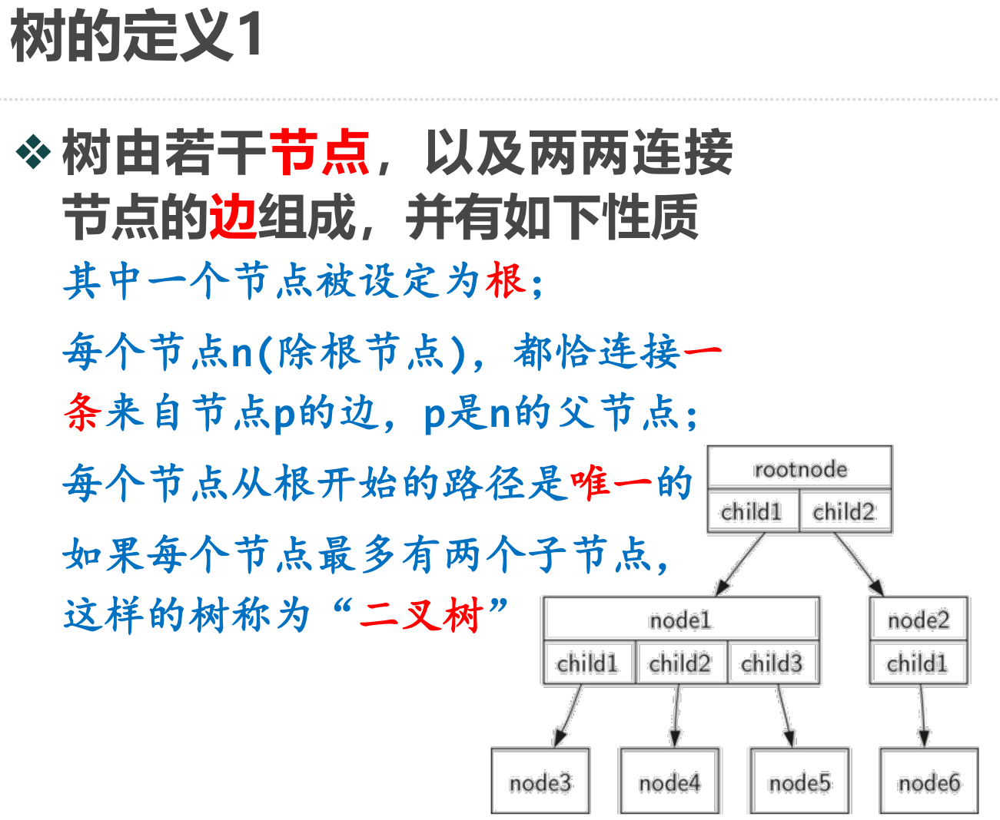

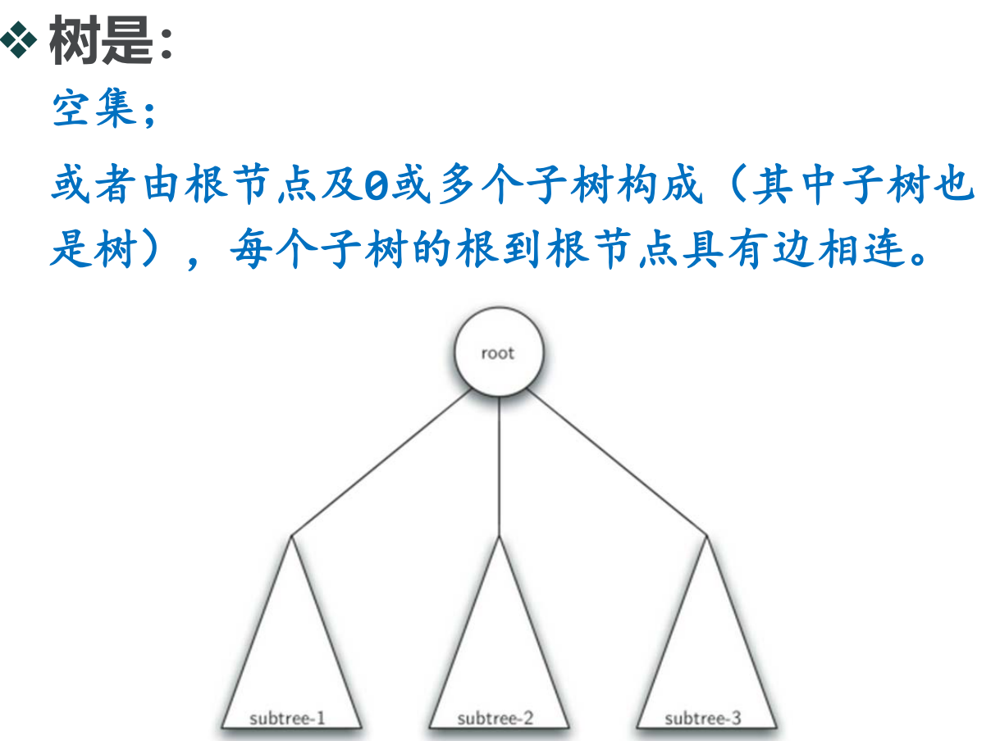

树的存储结构：

1.双亲表示法

2.孩子表示法

3.孩子兄弟表示法

https://blog.csdn.net/Real_Fool_/article/details/113930623

In [2]:
class treeNode():
    def __init__(self, value=None):
        self.value = value
        self.left = None
        self.right = None

    def getval(self):
        return self.value

    def setval(self, val):
        self.value = val

    def insert_left(self,node):
        self.left = treeNode(node)
        self = self.left
        return self

    def insert_right(self, node):
        self.right = node
        self = self.right
        return self



In [3]:
def completed_tree(string):
    list = []
    s = []
    for i in string:
        list.append(i)

    tree = treeNode("")
    s.append(tree)#多压一层栈的目的在于在避免多次弹栈导致栈为空，多出现在一个表达式的结束部分
    current = tree#"((4+5)*(5-3))"比如这个表达式，在最后运行3))的时候会弹栈三次

    for char in list:
        if char == "(":
            current.left = treeNode("")
            s.append(current)
            current = current.left
        elif char not in ["+","-","*","/",")"]:
            current.setval(int(char))
            current = s.pop()
        elif char in ["+","-","*","/"]:
            current.setval(char)
            current.right = treeNode("")
            s.append(current)
            current = current.right
        elif char == ")":
            current = s.pop()
        else :
            return ValueError
    return tree


string = "((4+5)*(5-3))"
tree = completed_tree(string)

In [4]:
import operator

dict = {"+":operator.add,"-":operator.sub,
            "*":operator.mul,"/":operator.truediv}

def evaluate(tree):
    if tree:
        left = evaluate(tree.left)
        right = evaluate(tree.right)
        if left and right:
            return dict[tree.getval()](left, right)
        else:
            return tree.getval()

print(evaluate(tree))

18


In [12]:
def sort(tree):
    if tree:
        left = sort(tree.left)
        right = sort(tree.right)
        if left and right:
            return '('+left+str(tree.getval())+right+")"
        else:
            return str(tree.getval())

print(sort(tree))

((4+5)*(5-3))


In [14]:
def printexp(tree):
    if tree.left and tree.right:
        val = "("+printexp(tree.left)
        val = val+str(tree.getval())
        val = val+printexp(tree.right)+")"
        return val
    else:
        return str(tree.getval())
print(printexp(tree))

((4+5)*(5-3))


树的遍历：

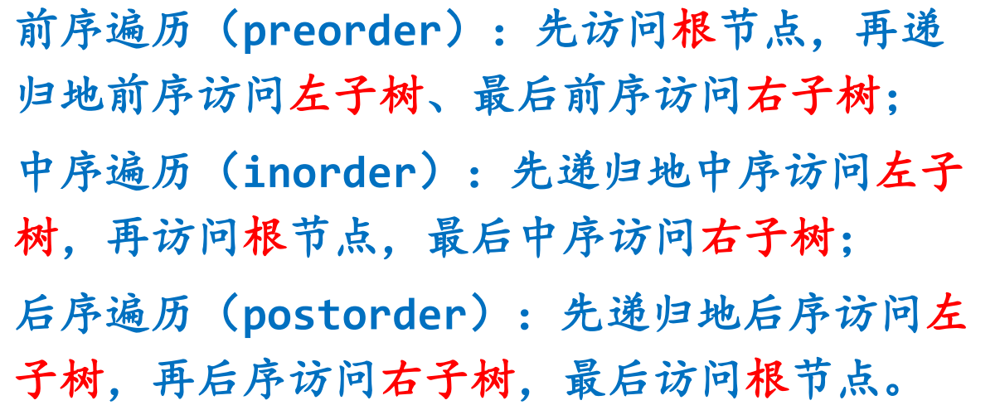

In [ ]:
def Preorder(tree):
    if tree:
        print(tree.getval())
        inorder(tree.left)
        inorder(tree.right)
Preorder(tree)

先序遍历的非递归实现：

In [ ]:
def inorderTraversal(root):
    list1,stack,curr = [],[],root
    while curr or stack:#第一次进入时是指针不空栈为空，后续遍历时会遇到指针为空栈不空的情况，最后退出时都为空
        while curr:
            list1.append(curr.val)
            stack.append(curr)
            curr = curr.left
        curr = stack.pop()#弹出父级节点，并让curr指向父级节点的右孩子从而继续进行遍历。
        curr = curr.right
    return list1

In [ ]:
def inorder(tree):
    if tree:
        inorder(tree.left)
        print(tree.getval())
        inorder(tree.right)
inorder(tree)

中序遍历的非递归实现：

In [ ]:
def inorder(root):
    list1,stack,curr = [],[],root
    while curr or stack:
        while curr:
            stack.append(curr)
            curr=curr.next
        curr = stack.pop()
        list1.append(curr.val)
        curr = curr.right
    return list1

In [ ]:
def postorder(tree):
    if tree:
        inorder(tree.left)
        inorder(tree.right)
        print(tree.getval())
postorder(tree)

后序遍历的非递归实现：

In [ ]:
def postorderTraversal(root):
    result = []
    stack = []
    prev = None  # 记录前一个访问的节点
    curr = root

    while curr or stack:
        # 一直向左走到底
        while curr:
            stack.append(curr)
            curr = curr.left

        curr = stack[-1]  # 查看栈顶元素但不弹出

        # 如果右子树存在且未被访问过
        if curr.right and curr.right != prev:
            curr = curr.right
        else:
            # 访问当前节点
            result.append(curr.val)
            stack.pop()
            prev = curr
            curr = None  # 避免重复访问左子树

    return result

优先队列与二叉堆：
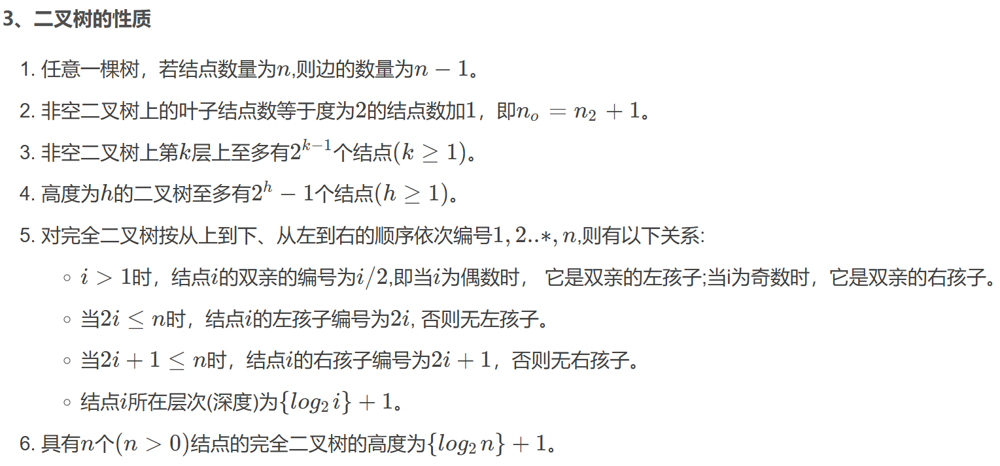

In [ ]:
class priority_quenue():
    def __init__(self):
        self.size = 0
        self.list = [0]

    def insert(self,item):
        self.list.append(item)
        self.size += 1
        self.exchange(self.size)

    def exchange(self,size):
        stop = False
        while size > 1 and not stop:
            stop = True
            if self.list[size] < self.list[size // 2]:
                temp = self.list[size]
                self.list[size] = self.list[size // 2]
                self.list[size // 2] = temp
                stop = False
            size = size // 2

    def delmin(self,i):
        removal = self.list[i]
        self.list[i] = self.list[self.size]
        self.size -= 1
        self.list.pop()
        self.exchange_to_bottom(i)

    def exchange_to_bottom(self,i):
        stop = False
        while 2*i <= self.size and not stop:#当2*i的值大于self.size的时候，已经下沉到叶子节点，当前节点不可能有子节点
            stop = True
            num=self.small(i)
            if self.list[num] < self.list[i]:
                stop = False
                temp=self.list[i]
                self.list[i]=self.list[num]
                self.list[i]=temp
                i = num

    def small(self,i):
        if 2*i+1 > self.size:
            return 2*i
        else:
            if self.list[2*i]>self.list[2*i+1]:
                return 2*i+1
            else:
                return 2*i

    def build_head_list(self,list):
        length = len(list)
        self.list = [0]+list
        for i in range(length//2,0,-1):
            self.exchange_to_bottom(i)
        return self.list


二叉堆排序：（时间复杂度为n*log(n)）

In [ ]:
def sort_binary(list):
    length = len(list)
    list = [0]+list
    while length > 1:
        temp = list[1]
        list[1] = list[length]
        list[length] = temp
        length -= 1
        list.exchange_to_bottom(length)

二叉查找树（与二叉堆不同)

In [52]:
class tree_node():
    def __init__(self,key,value,parent=None):
        self.key = key
        self.value = value
        self.parent = parent
        self.left = None
        self.right = None
        self.balanceFactor = 0
        self.height = 1

class binary_search_tree():
    def __init__(self):
        self.root = None
        self.size = 0

    def __setitem__(self,key,value):
        self._put(key,value)

    def current_replacement(self,node,key,value,left,right):
        node.key =key
        node.value = value
        node.left = left
        node.right = right

    def put(self,key,value):
        if self.root == None:
            self.root = tree_node(key,value,None)
        else:
            self.__put(self.root,key,value)
        self.size += 1

    def __put(self,node,key,value):
        if key < node.key:
            if node.left:
                self.__put(node.left,key,value)
            else:
                node.left = tree_node(key,value,node)
        else:
            if node.right:
                self.__put(node.right,key,value)
            else:
                node.right = tree_node(key,value,node)


    def __getitem__(self,key):
        return self.get(key)#注意返回值

    def get(self,key):
        if self.root:
            res = self.__get(key,self.root)
            if res:
                return res
            else:
                return None
        else:
            return None

    def __get(self,key,node):
        if not node:
            return None
        elif key < node.key:
            return self.__get(key,node.left)
        elif key > node.key:
            return self.__get(key,node.right)
        else:
            return node

    def __contains__(self,key):
        if self.get(key):
            return True
        else:
            return False

    def delete(self,key):
        node = self.get(key)
        if node:
            if not node.left and not node.right:
                if node.parent.left==node:
                    node.parent.left=None
                else:
                    node.parent.right=None
            elif node.left and not node.right:
                if node.parent.left==node:
                    node.left.parent = node.parent
                    node.parent.left = node.left
                elif node.parent.right==node:
                    node.parent.left = node.right
                    node.right.parent = node.parent
                else:
                    self.current_replacement(node,node.left.key,node.left.value,
                                             node.left.left,node.left.right)

            elif node.right and not node.left:
                if node.parent.right==node:
                    node.parent.right = node.right
                    node.right.parent = node.parent
                elif node.parent.right==node:
                    node.parent.right = node.left
                    node.left.parent = node.parent
                else:
                    self.current_replacement(node,node.right.key,node.right.value,
                                             node.right.left,node.right.right)
            else:
                min_node=self.findmin(node.right)
                if not min_node.left and not min_node.right:
                    if min_node.parent.left==min_node:
                        min_node.parent.left=None
                    else:
                        min_node.parent.right=None
                else:
                    min_node.parent.left = min_node.right
                    min_node.right.parent = min_node.parent
                node.key = min_node.key
                node.value = min_node.value

    def findmin(self,node):
        if node.left:
            self.findmin(node.left)
        else:
            return node

    def _put(self,key,value):
        if self.root:
            self.put_avl(self.root,key,value)
        else:
            self.root = tree_node(key,value,None)

    def put_avl(self,node,key,value):
        if key<node.key:
            if node.left:
                self.put_avl(node.left,key,value)
            else:
                node.left = tree_node(key,value,node)
                self.balance(node.left)
        else:
            if node.right:
                self.put_avl(node.right,key,value)
            else:
                node.right = tree_node(key,value,node)
                self.balance(node.right)

    def balance(self,node):
        if node.balanceFactor >1 or node.balanceFactor < -1:
            self.rebalance(node)#找寻到最小不平衡子树的根节点后对它进行旋转操作，旋转完后不需在继续向上检查，因为再插入这个节点前树已经是平衡的了，旋转完后所有的节点都平衡
            return

        if node.parent:
            if node.parent.left==node:
                node.parent.balanceFactor +=1
            else :
                node.parent.balanceFactor -=1

            if node.parent.balanceFactor:
                self.balance(node.parent)

    # def _update_balance_after_delete(self, node):
    # while node is not None:
    #     # 更新节点高度和平衡因子
    #     self._update_height(node)
    #
    #     # 检查是否失衡
    #     if abs(node.balanceFactor) > 1:
    #         node = self.rebalance(node)
    #         # 旋转后高度可能变化，继续向上检查
    #         if node.balanceFactor == 0 and node.parent is not None:
    #             node = node.parent
    #             continue
    #         else:
    #             break
    #     # 如果高度没有变化，停止向上更新
    #     elif node.balanceFactor == 0:
    #         if node.parent is not None:
    #             node = node.parent
    #             continue
    #         else:
    #             break
    #     # 如果高度变化但未失衡，继续向上更新
    #     else:
    #         break
    #
    # # 如果当前节点的平衡因子为±1，则停止更新，因为高度没有变化
    # # 注意：删除操作中，如果节点平衡因子变为±1，说明之前是0，现在高度不变，所以不会影响上层节点

    def rotate_left(self,row_node):
        new_node = row_node.right
        row_node.right = new_node.left
        if new_node.left:
            new_node.left.parent = row_node
        new_node.parent = row_node.parent
        if not new_node.parent:
            self.root = new_node
        else:
            if row_node.parent.left==row_node:
                row_node.parent.left = new_node
            else:
                row_node.parent.right = new_node
        new_node.left = row_node
        row_node.parent = new_node
        # row_node.balanceFactor = row_node.balanceFactor + 1 - min(new_node.balanceFactor,0)递归时不需要
        # new_node.balanceFactor = new_node.balanceFactor + 1 + max(row_node.balanceFactor,0)

    def rotate_right(self,row_node):#三对父与子（旧节点与新结点的子节点，新节点与旧节点的父节点，旧节点与新节点）
        new_node = row_node.left
        row_node.left = new_node.right
        if new_node.right:
            new_node.right.parent = row_node
        new_node.parent = row_node.parent
        if not new_node.parent:
            self.root = new_node
        else:
            if row_node.parent.left==row_node:
                row_node.parent.left = new_node
            else:
                row_node.parent.right = new_node
        new_node.right = row_node
        row_node.parent = new_node

        # row_node.balanceFactor = row_node.balanceFactor + 1 - min(new_node.balanceFactor,0)
        # new_node.balanceFactor = new_node.balanceFactor + 1 + max(row_node.balanceFactor,0)

In [ ]:
    def get_height(self,node):
        if node:
            return node.height
        else:
            return 0

    def rotate_RR(self,node):#右旋
        y = node.left
        T2 = y.right

        node.left = T2
        y.right = node

        node.height = 1 + max(self.get_height(y.right),self.get_height(node.right))
        y.height = 1 + max(self.get_height(y.left),self.get_height(node))

        return y

    def rotate_LL(self,node):#左旋
        y = node.right
        T2 = y.left

        node.right = T2
        y.left = node

        node.height = 1 + max(self.get_height(y.left),self.get_height(node))
        y.height = 1 + max(self.get_height(y.right),self.get_height(node))

        return y

    def avl_insert(self,node,key):
        if not node:#当没有节点时创建节点，使得在后续的高度计算中不会遇到node.left与node.right为空的情况。
            return tree_node(key,None,None)
        elif key < node.key:
            node.left = self.avl_insert(node.left,key)
        else:
            node.right = self.avl_insert(node.right,key)

        node.height = 1 + max(self.get_height(node.left),self.get_height(node.right))
        node.balanceFactor = node.left.height - node.right.height

        if node.balanceFactor >1 or node.balanceFactor < -1:
            if node.balanceFactor>1:
                if node.left.balanceFactor > 0:#LL
                   return self.rotate_RR(node)
                else:#LR
                    node.left = self.rotate_LL(node.left)
                    return self.rotate_RR(node)
            else :
                if node.right.balanceFactor > 0:
                    return self.rotate_LL(node)
                else:
                    node.right = self.rotate_RR(node.right)
                    return self.rotate_LL(node)

        return node

    def avl_delete(self,node,value):#不需要使用父亲属性
        if value < node.key:
            node.left = self.avl_delete(node.left,value)
        elif value > node.key:
            node.right = self.avl_delete(node.right,value)
        else:
            if not node.left:#没有孩子或者没有左孩子
                return node.left

            if not node.right:#没有右孩子
                return node.left

            else:#有两个孩子
                min_node = self.findmin(node.right)
                node.key = min_node.key
                node.right = self.avl_delete(node.right,min_node.key)


        node.height = 1 + max(
        self.get_height(node.left) if node.left else 0,
        self.get_height(node.right) if node.right else 0
        )

        # 计算平衡因子
        left_height = self.get_height(node.left) if node.left else 0
        right_height = self.get_height(node.right) if node.right else 0
        node.balanceFactor = left_height - right_height

        if node.balanceFactor >1 or node.balanceFactor < -1:
            if node.balanceFactor>1:
                if node.left.balanceFactor > 0:#LL
                    return self.rotate_RR(node)
                else:#LR
                    node.left = self.rotate_LL(node.left)
                    return self.rotate_RR(node)
            else :
                if node.right.balanceFactor > 0:
                    return self.rotate_LL(node)
                else:
                    node.right = self.rotate_RR(node.right)
                    return self.rotate_LL(node)

        return node

In [57]:
mytree = binary_search_tree()
mytree[3] = "f"#调用了set item函数
mytree[4] = "x"
mytree[6] = "e"
mytree[2] = "q"
mytree[7] = "t"
mytree[8] = "a"
print(mytree.get(6).value)
print(mytree[3].value)#调用了getitem方法,该方法返回一个节点
# mytree.delete(3)
# print(3 in mytree)#调用了container方法
print(mytree[6].balanceFactor)


e
f
-2


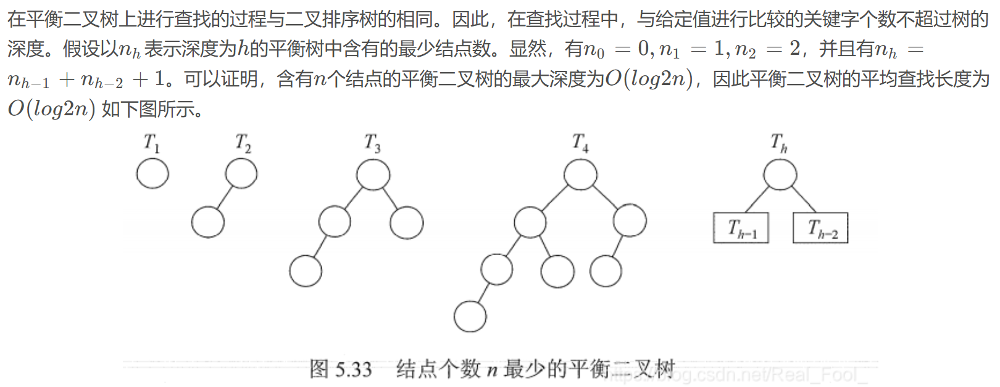

把左旋与右旋的过程理解为提拉东西，把中间的点往上提（针对LL型以及RR型以及LR型和RL型的最后一步）

左重右旋，右重左旋，旋转的结果是使新的节点（new）提到上边来。

左旋：逆时针旋转，冲突的左孩变右孩  右旋：顺时针旋转，冲突的右孩变孩  针对的对象是最小不平衡树的根节点



LL型：使不平衡树的根节点右旋（沿着左子节点顺时针转）

RR型：使不平衡树的根节点左旋（沿着右子节点顺时针转）

LR型：先使不平衡树的根节点的左孩子沿着其右孩子左旋，再使不平衡树的根节点右旋

RL型：先使不平衡树的根节点的右孩子沿着其左孩子右旋，再使不平衡树的根节点左旋

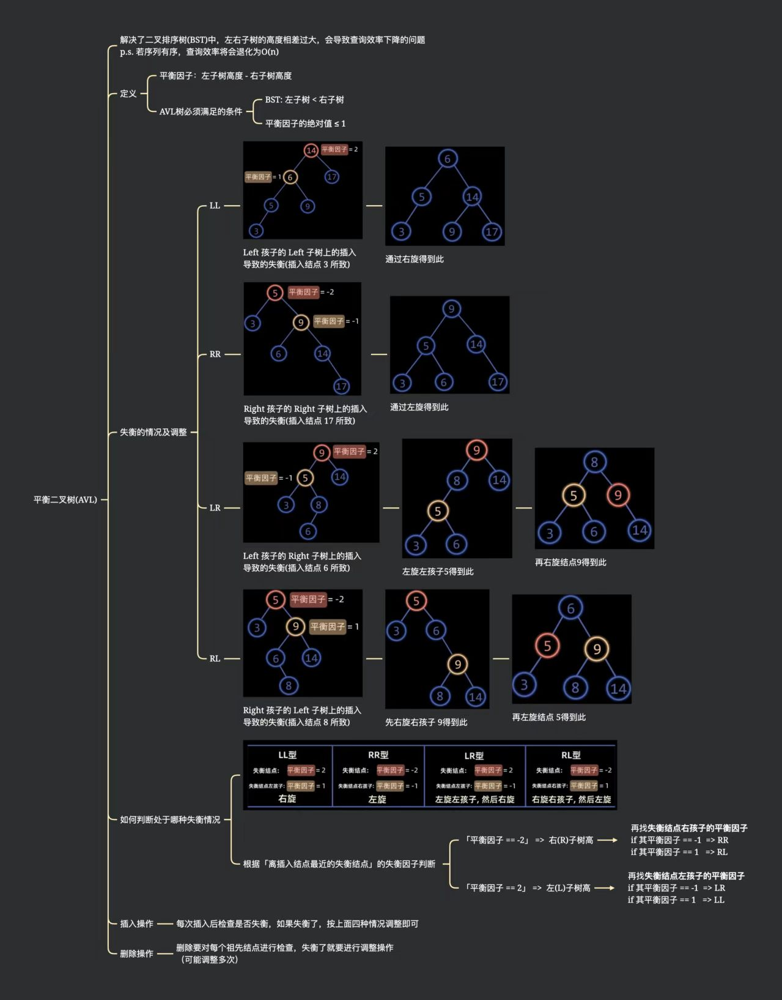

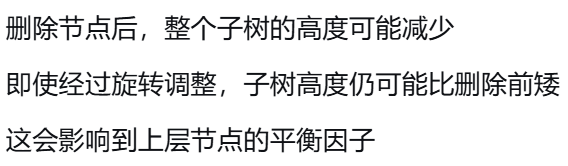

线索二叉树：

前驱与后继：指一个节点在前序中序后序序列中的左右节点

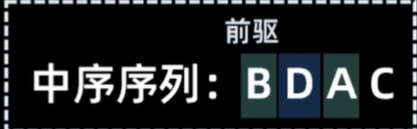



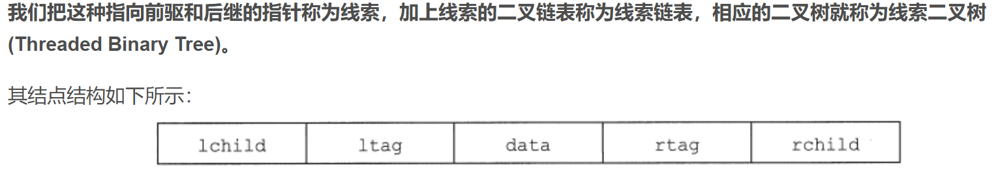



构建中序线索二叉树：构建时用到递归

        void InThread(ThreadTree p, ThreadTree pre){
            if(p != NULL){
                InThread(p->lchild, pre);	//递归，线索化左子树
                if(p->lchild == NULL){	//左子树为空，建立前驱线索
                    p->lchild = pre;
                    p->ltag = 1;
                }
                if(pre != NULL && pre->rchild == NULL){
                    pre->rchild = p;	//建立前驱结点的后继线索
                    pre->rtag = 1;
                }
                pre = p;	//标记当前结点成为刚刚访问过的结点
                InThread(p->rchild, pre);	//递归，线索化右子树
            }
        }

        void CreateInThread(ThreadTree T){
            ThreadTree pre = NULL;
            if(T != NULL){
                InThread(T, pre);	//线索化二叉树
                pre->rchild = NULL;	//处理遍历的最后一个结点
                pre->rtag = 1;
            }
        }


中序线索二叉树的遍历：

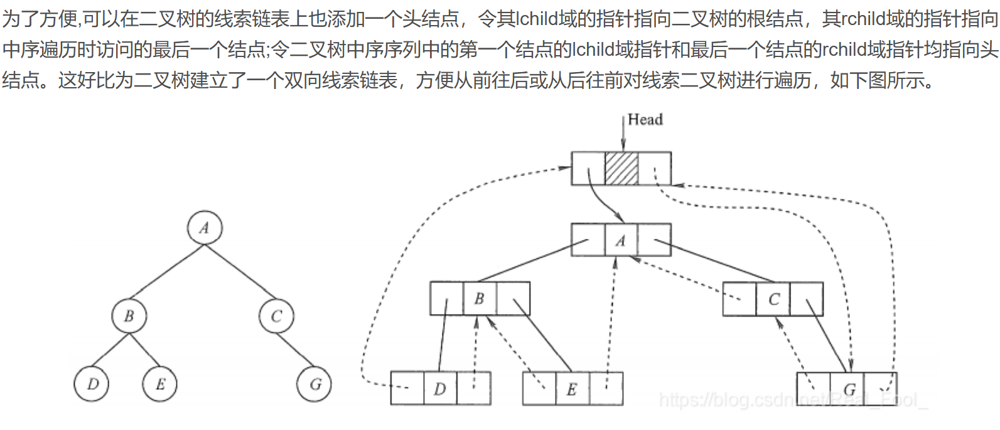


        /*T指向头结点，头结点左链lchild指向根结点，头结点右链rchild指向中序遍
        的最后一个结点。中序遍历二叉线索链表表示的二叉树T*/
        void InOrderTraverse_Thr(BiThrTree T){
            BiThrTree p;
            p = T->lchild;	//p指向根结点
            //空树或遍历结束时，p==T（最后一个结点指向根结点）
            while(p != T){
                //当ltag==0时循环到中序序列第一个结点
                while(p->ltag == 0){
                    p = p->lchild;	//p指向p的左子树
                }
                visit(p);	//访问该结点
                //后继线索为1且不是指向头指针，因为头节点不需要打印
                while(p->rtag == 1 && p->rchild != T){
                    p = p->rchild;	//p指向p的后继
                    visit(p);	//访问该节点
                }
                //p进至其右子树根，开始对右子树根进行遍历，能执行到这一步意味着当前节点有右孩子。
                p = p->rchild;
            }
        }


构建先序线索二叉树：

         void InThread(ThreadTree p, ThreadTree pre){
                    if(p != NULL){
                        if(p->lchild == NULL){	//左子树为空，建立前驱线索
                                p->lchild = pre;
                                p->ltag = 1;
                            }
                            if(pre != NULL && pre->rchild == NULL){
                                pre->rchild = p;	//建立前驱结点的后继线索
                                pre->rtag = 1;
                            }
                        pre = p;	//标记当前结点成为刚刚访问过的结点
                        InThread(p->lchild, pre);	//递归，线索化左子树
                        InThread(p->rchild, pre);	//递归，线索化右子树
                    }
                }

                void CreateInThread(ThreadTree T){
                    ThreadTree pre = NULL;
                    if(T != NULL){
                        InThread(T, pre);	//线索化二叉树
                        pre->rchild = NULL;	//处理遍历的最后一个结点
                        pre->rtag = 1;
                    }
                }
先序二叉树遍历：

        void PreOrderTraverse_Thr(BiThrTree T){
            BiThrTree p = T->lchild;  // p指向根结点

            while(p != T){
                visit(p);  // 先访问当前节点（前序特点）

                if(p->ltag == 0){
                    // 有左孩子，继续向左
                    p = p->lchild;
                } else {
                    // 没有左孩子，转向右子树或后继，后继是其他节点的右子树而非父节点
                    p = p->rchild;
                }
            }
        }

构建后序线索二叉树：

        // 全局变量，记录前驱节点
        BiThrTree pre = NULL;

        void PostThread(BiThrTree p) {
            if (p != NULL) {
                PostThread(p->lchild);  // 递归线索化左子树
                PostThread(p->rchild);  // 递归线索化右子树

                // 处理当前节点的前驱线索
                if (p->lchild == NULL) {
                    p->lchild = pre;
                    p->ltag = 1;
                }

                // 处理前驱节点的后继线索
                if (pre != NULL && pre->rchild == NULL) {
                    pre->rchild = p;
                    pre->rtag = 1;
                }

                pre = p;  // 更新前驱节点
            }
        }

        // 创建后序线索二叉树
        void CreatePostThread(BiThrTree T) {
            if (T != NULL) {
                PostThread(T);
                // 处理最后一个节点的右线索
                if (pre->rchild == NULL) {
                    pre->rtag = 1;
                }
            }
        }

后序二叉树的遍历：

    // 找到后序遍历的第一个节点
    BiThrTree FirstPostNode(BiThrTree p) {
        if (p == NULL) return NULL;

        // 优先向左子树递归
        if (p->ltag == 0) {
            return FirstPostNode(p->lchild);
        }
        // 没有左子树但有右子树，向右子树递归
        else if (p->rtag == 0) {
            return FirstPostNode(p->rchild);
        }
        // 既没有左子树也没有右子树，就是第一个节点
        else {
            return p;
        }
    }

    // 后序线索二叉树遍历
    void PostOrderTraverse_Thr(BiThrTree T) {
        BiThrTree p = FirstPostNode(T);  // 找到第一个节点

        while (p != T) {  // 假设T是头节点
            visit(p);

            // 如果p是父节点的右孩子，或者父节点没有右孩子（只有一个孩子的情况）
            if (p->parent != NULL &&
                (p->parent->rtag == 1 || p == p->parent->rchild)) {
                p = p->parent;
            }
            // 如果p是父节点的左孩子且父节点有右孩子（两个孩子都有的情况）
            else if (p->parent != NULL && p == p->parent->lchild &&
                     p->parent->rtag == 0) {
                p = FirstPostNode(p->parent->rchild);
            }
        }
    }

树、森林与二叉树的转换

哈夫曼树

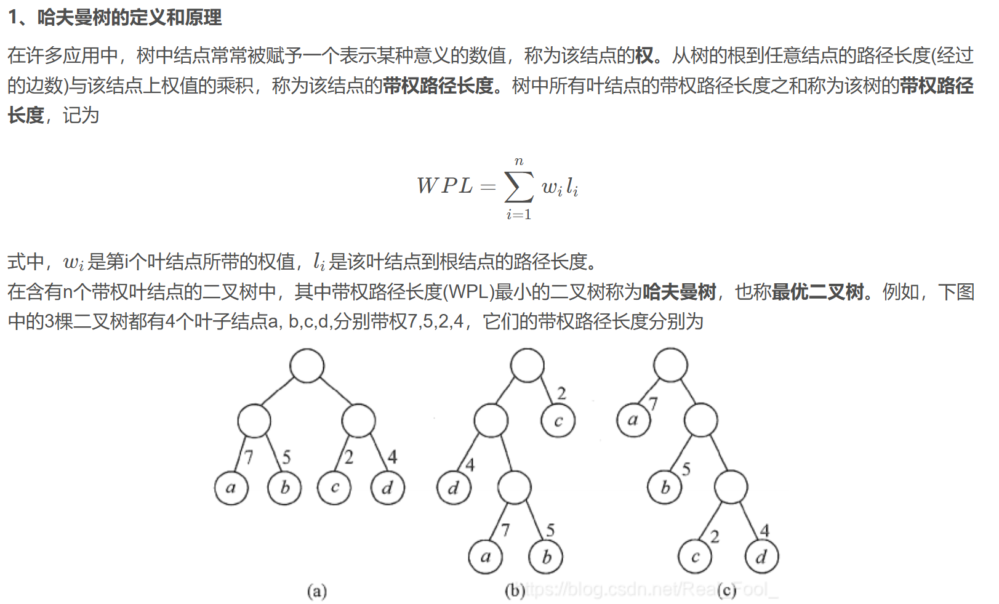

构建：每次取两个值，取出后将数合并放入到原队列中，继续寻找最小的两个值。

对于一个含有n个节点的哈夫曼树而言，需要合并n-1次。

In [17]:
class hauffle_tree_node():
    def __init__(self,weight):
        self.weight = weight
        self.left = None
        self.right = None
        self.parent = None

def hauffle_tree(list_of_nodes):

   length = len(list_of_nodes)
   for x in range(length,2*length-1):
       list_of_nodes.append(hauffle_tree_node(0))
   for i in range(length,2*length-1):#当i停在n的时候还没有值,对于一个含有n个节点的哈夫曼树而言，需要合并n-1次。
       small1,small2 = float('inf'),float('inf')
       p1,p2 = 0,0
       for j in range(i):
           if not list_of_nodes[j].parent:
               if list_of_nodes[j].weight<small1:
                   small2 = small1
                   small1 = list_of_nodes[j].weight
                   p2 = p1
                   p1 = j
               elif list_of_nodes[j].weight<small2:
                   small2 = list_of_nodes[j].weight
                   p2 = j
       list_of_nodes[p1].parent = list_of_nodes[i]
       list_of_nodes[p2].parent = list_of_nodes[i]
       list_of_nodes[i].weight = list_of_nodes[p1].weight + list_of_nodes[p2].weight
       list_of_nodes[i].left = list_of_nodes[p1]
       list_of_nodes[i].right = list_of_nodes[p2]

   return list_of_nodes

def print_haffule(list_of_nodes,n):
    for x in range(n,len(list_of_nodes)):
        print(list_of_nodes[x].weight)


n=10
list_of_nodes = [hauffle_tree_node(i) for i in range(n)]
list1 = hauffle_tree(list_of_nodes)
print_haffule(list1,n)

1
3
6
9
12
15
18
27
45


红黑树插入

当插入节点的叔叔节点为空需要改变结构时，只有父亲节点与爷爷节点需要变换颜色。

红黑树的插入需要参考叔叔节点

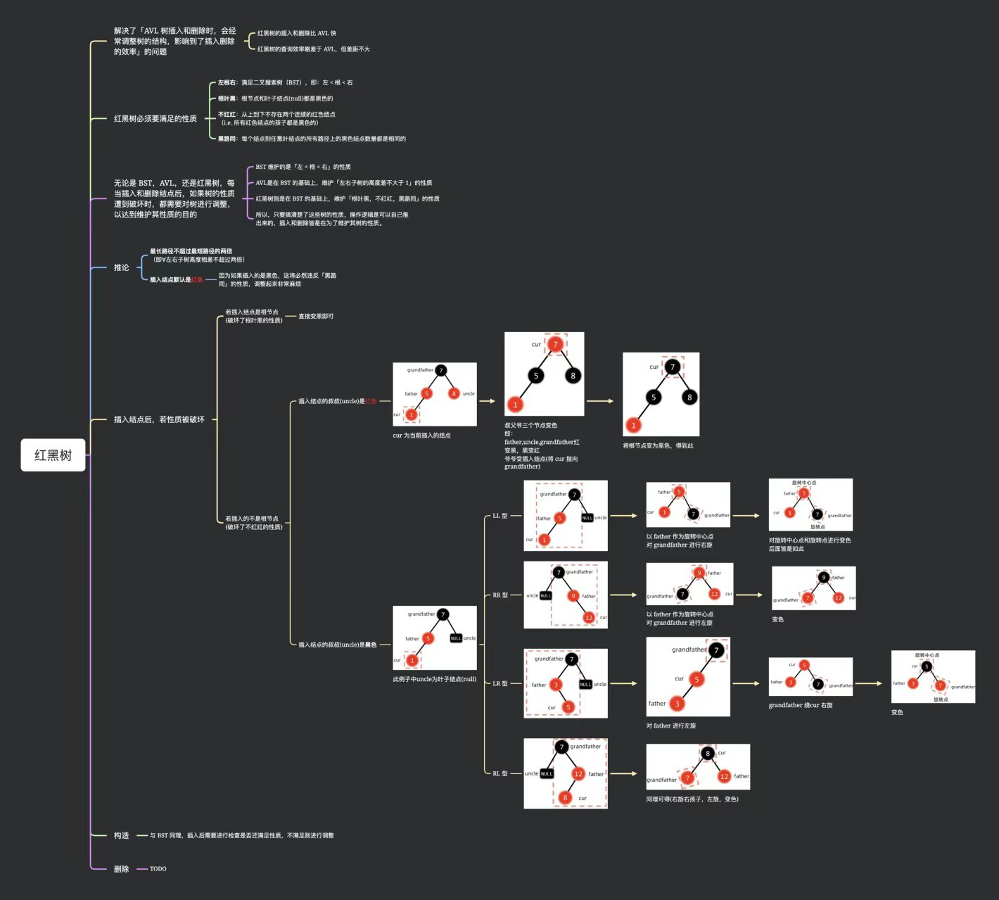

In [ ]:
class tree_node():
    def __init__(self,value,parent,color="red"):
        self.value = value
        self.left = None
        self.right = None
        self.parent = parent
        self.color = color

class red_black_tree():
    def __init__(self):
        self.root = None
    def insert(self,node,value):
        if self.root is None:
            self.root = tree_node(value,"black")
        else:
            self.put_avl(node,value)

    def put_avl(self,node,value):
            if value<node.value:
                if node.left:
                    self.put_avl(node.left,value)
                else:
                    node.left = tree_node(value,node)
                    self.balance(node.left)
            else:
                if node.right:
                    self.put_avl(node.right,value)
                else:
                    node.right = tree_node(value,node)
                    self.balance(node.right)

    def balance(self,node):
        if node.parent.color == "black":
            return
        parent = node.parent
        grandparent = parent.parent
        if grandparent.left == parent:
            uncle = grandparent.right
        else:
            uncle = grandparent.left

        if parent.color == "red":
            if uncle and uncle.color == "red":
                parent.color = "black"
                uncle.color = "black"
                grandparent.color = "red"
                self.balance(grandparent)
            elif not uncle or uncle.color == "black":
                if grandparent.left == parent:
                    if parent.right == node:
                        self.rotate_left(parent)
                        node = parent
                        parent = node.parent
                    self.rotate_right(grandparent)
                    parent.color = "black"
                    grandparent.color = "red"
                else:
                    if parent.left == node:
                        self.rotate_right(parent)
                        node = parent
                        parent = node.parent
                    self.rotate_left(grandparent)
                    parent.color = "black"
                    grandparent.color = "red"

    def rotate_left(self,row_node):#对于左旋与右旋操作而言，传入的是row节点，也就是需要旋转的节点，较上层的节点。
        new_node = row_node.right
        row_node.right = new_node.left
        if new_node.left:
            new_node.left.parent = row_node
        new_node.parent = row_node.parent
        if not new_node.parent:
            self.root = new_node
        else:
            if row_node.parent.left==row_node:
                row_node.parent.left = new_node
            else:
                row_node.parent.right = new_node
        new_node.left = row_node
        row_node.parent = new_node

    def rotate_right(self,row_node):#三对父与子（旧节点与新结点的子节点，新节点与旧节点的父节点，旧节点与新节点）
        new_node = row_node.left
        row_node.left = new_node.right
        if new_node.right:
            new_node.right.parent = row_node
        new_node.parent = row_node.parent
        if not new_node.parent:
            self.root = new_node
        else:
            if row_node.parent.left==row_node:
                row_node.parent.left = new_node
            else:
                row_node.parent.right = new_node
        new_node.right = row_node
        row_node.parent = new_node

红黑树的删除操作：

删除需要参考兄弟节点
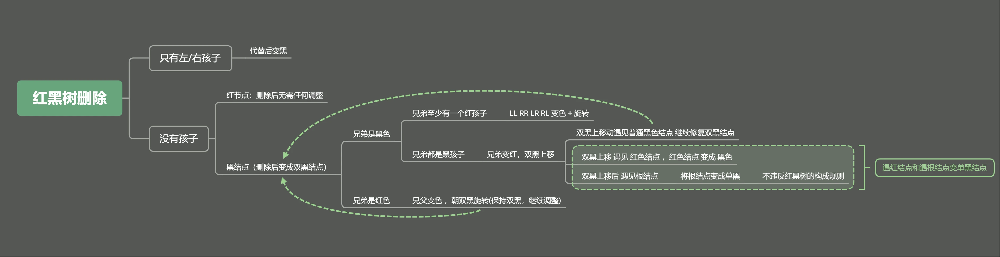

1. 只有左右孩子时只能是一黑一红
2. LL,RR变色是让r变s，s变p，p变黑
3. LR,RL变色是让r变p，p变黑
4. 如果兄弟有两个红孩子的话，先往RR，LL型去凑。
5. 兄弟是红色朝双黑节点旋转的含义是使双黑节点位于父节点的下方，二者都位于兄弟节点的同一个分支上

**_#B树_**

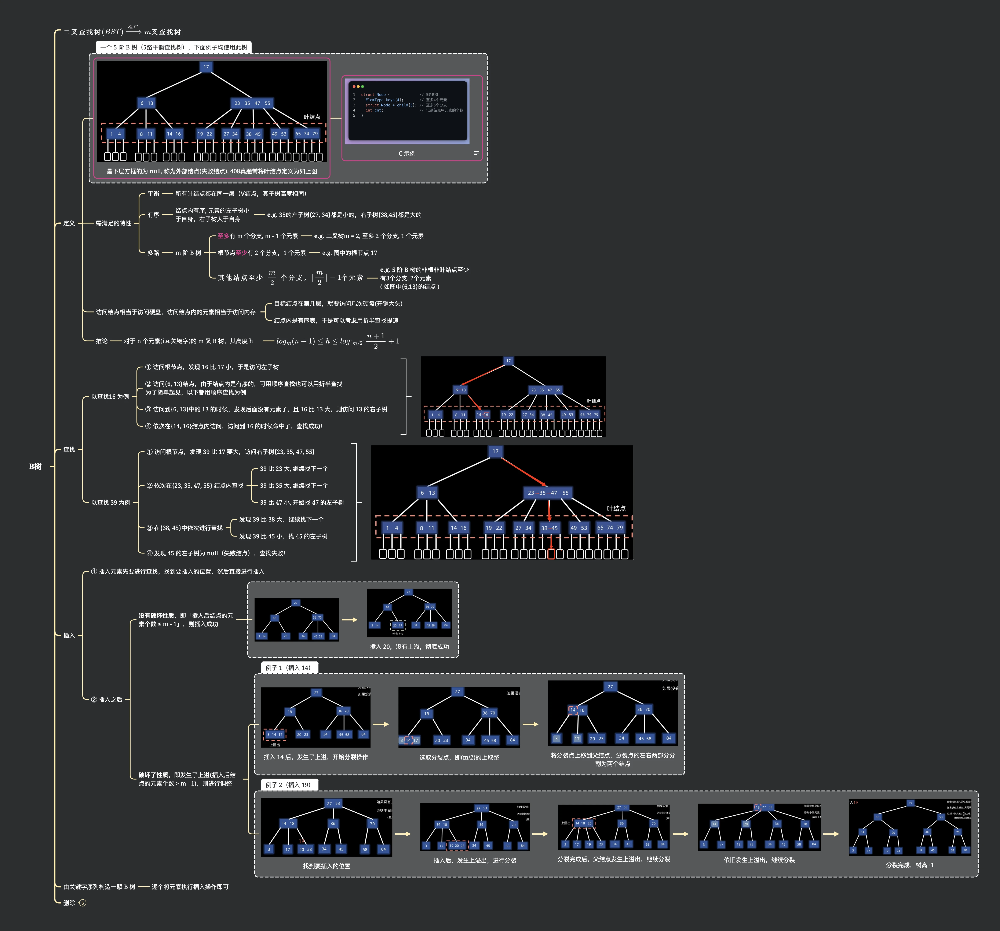

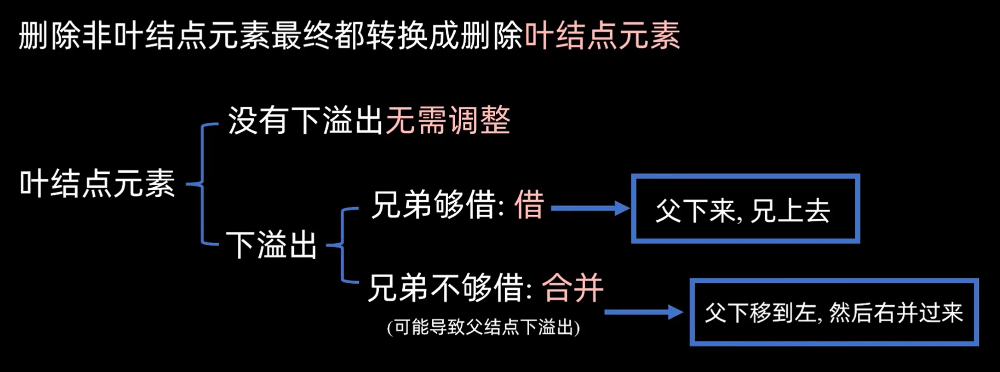
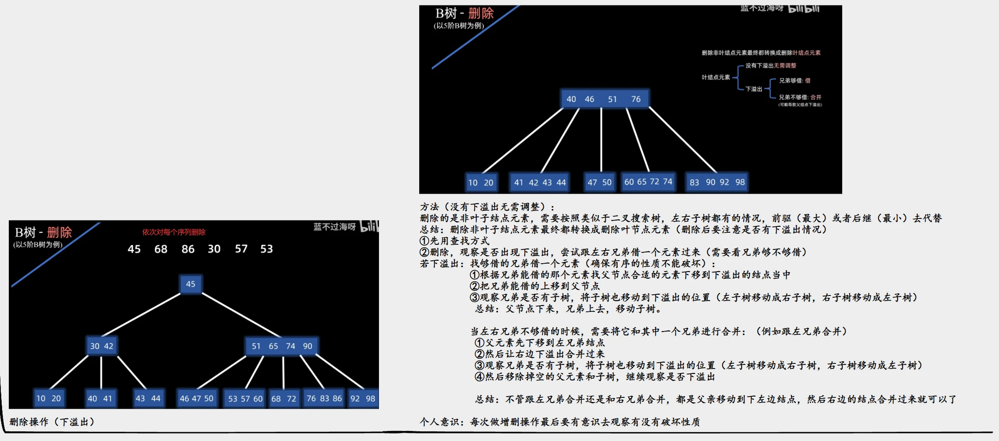

在兄弟不够借的情况下，合并时如果节点有子树的话，也需要将子树同时移动过去。这种情况下父下移到左，然后右并过来是统一操作。

删除非叶节点元素，先找这个元素的直接前驱或者直接后继，数值替换后转换为删除叶节点的问题。

在兄弟够借的情况下，如果右兄弟有子树，需要将兄弟的左子树也移动过去。反之相反即可。

跟左兄弟借，将父节点下移，同时将左兄弟的最后一个元素上移；跟右兄弟借，将父节点下移，同时将右兄弟的第一个元素上移。


**_#B+树_**

1. B+树的叶节点包含所有元素，从小到大连接起来。可以顺序查找
2. B+树的元素数与分支数相同，例如三阶B树最多可以有三个分支，三个元素

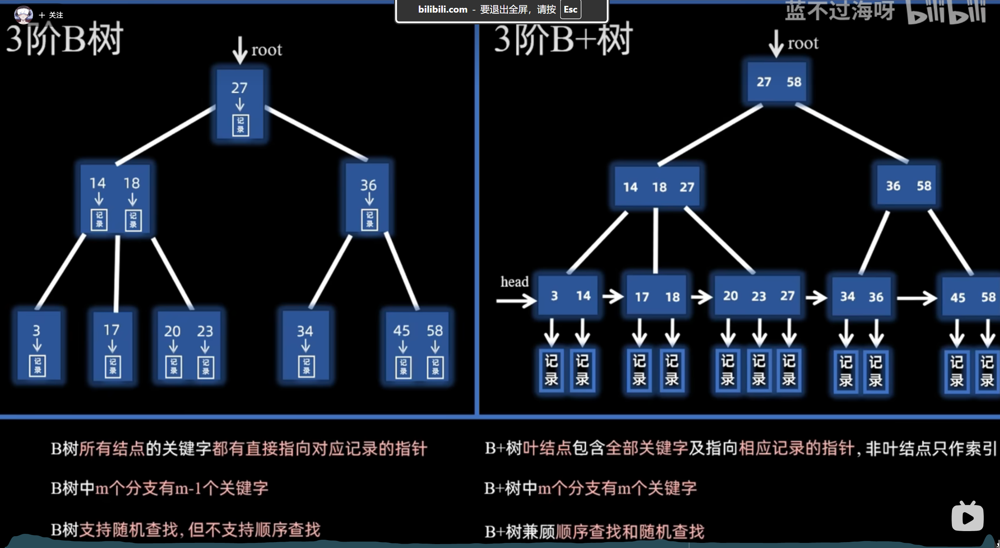